# `DomainMesh` — Tutorial

`DomainMesh` is the mesh-based counterpart of `DomainCubic`.  Instead of an
axis-aligned box it accepts any triangular (2-D) or tetrahedral (3-D) mesh
and provides the same region / sampling / visualisation API.

Built-in mesh builders live in `pinns.meshes` (require **pygmsh**):

| Builder | Shape |
|---|---|
| `meshes.square(x_max, y_max, mesh_size)` | Rectangle `[0, x_max] × [0, y_max]` |
| `meshes.disk(radius, center, mesh_size)` | Circular disk |
| `meshes.annulus(inner_radius, outer_radius, …)` | Annular ring |
| `meshes.l_shape(size, mesh_size)` | L-shape (square minus top-right quadrant) |
| `meshes.u_shape(…)` | U-shaped channel (sharp corners) |
| `meshes.horse_shoe(…)` | U-shaped channel (rounded corners) |

All builders return `(verts, faces)` tuples, which `DomainMesh` accepts directly.
You can also pass a **trimesh**, **pymesh**, or **meshio** object, or any
`(vertices, faces)` tuple you construct yourself.

Once constructed, `DomainMesh` lets you:
1. Query geometric properties (node/face counts, boundary edges).
2. Register named interior and boundary sampling regions.
3. Sample points from any region for training.
4. Visualise the mesh with highlighted regions and boundary conditions.

## Imports

In [1]:
%matplotlib widget
import numpy as np
import pinns
from pinns.domain import DomainMesh
from pinns import meshes

---
## 1. Construction

`DomainMesh` accepts meshes from several sources:

| Input | Example |
|---|---|
| `(verts, faces)` tuple | `DomainMesh((verts, faces))` |
| trimesh / pymesh object | `DomainMesh(trimesh_obj)` |
| meshio mesh | `DomainMesh(meshio_mesh)` |
| `pinns.meshes` builder | `DomainMesh(meshes.disk())` |

The `pinns.meshes` module ships many ready-made meshes — 2-D domains
(`disk`, `square`, `annulus`, `l_shape`, `u_shape`, `horse_shoe`, …)
and 3-D surfaces (`sphere`, `open_sphere`, and 22 public models via
`meshes.get_mesh(name)` — call `help(meshes.get_mesh)` for the full catalogue).

The optional **`time`** argument works identically to `DomainCubic`:

| `time` argument | Mode |
|---|---|
| `None` *(default)* | Stationary — no time column |
| `(t_min, t_max)` | Continuous — uniform sampling in `[t_min, t_max]` |
| `[t0, t1, …, tn]` | Discrete — exactly these time levels |

In [2]:
# The pinns.meshes module provides ready-made triangular meshes.
# Use any of them directly with DomainMesh:
#
#   meshes.disk()          – circular disk
#   meshes.square()        – rectangle
#   meshes.annulus()       – ring / annulus
#   meshes.l_shape()       – L-shaped domain
#   meshes.u_shape()       – U-shaped domain (sharp corners)
#   meshes.horse_shoe()    – horseshoe domain (rounded corners)
#   meshes.sphere()        – 3-D unit sphere surface
#   meshes.get_mesh(name)  – any of 22 public 3-D models (bunny, teapot, …)
#                            call help(meshes.get_mesh) for the full catalogue
#
# Here we use a simple disk as the running example.

verts, faces = meshes.disk(radius=1.0, mesh_size=0.08)

# ── Stationary domain ─────────────────────────────────────────────────────────
d_stat = DomainMesh((verts, faces))

# ── Continuous time  t ∈ [0, 1] ───────────────────────────────────────────────
d_cont = DomainMesh((verts, faces), time=(0.0, 1.0))

# ── Discrete time steps ───────────────────────────────────────────────────────
d_disc = DomainMesh((verts, faces), time=np.linspace(0, 1, 11))

print("stationary disk :", d_stat)
print("continuous disk :", d_cont)
print("discrete   disk :", d_disc)

stationary disk : DomainMesh(2D, n_nodes=701, n_conditions=0)
continuous disk : DomainMesh(2D × t∈[0.0, 1.0] continuous, n_nodes=701, n_conditions=0)
discrete   disk : DomainMesh(2D × t∈[0.0, 1.0] discrete(10 steps), n_nodes=701, n_conditions=0)


---
## 2. Geometric properties

| Property | Description |
|---|---|
| `_vertices` | `(N, spatial_dims)` vertex coordinates |
| `_faces` | `(F, 3)` triangle vertex indices |
| `_spatial_dims` | number of spatial dimensions |
| `n_dims` | total dims (space + time) |
| `_time_mode` | `'stationary'` / `'continuous'` / `'discrete'` |
| `_t_min`, `_t_max` | time range (or `None` for stationary) |
| `_bnd_edges` | `(E, 2)` boundary edge vertex pairs |
| `_bnd_edge_lengths` | per-edge lengths |
| `_boundary_node_mask` | bool mask of boundary vertices |
| `xmin`, `xmax` | full (space + time) bounding box |

In [3]:
d = d_stat   # use the manual unit-disk as the running example

print(f"Vertices          : {d._vertices.shape}  (N, 2)")
print(f"Faces             : {d._faces.shape}  (F, 3)")
print(f"Spatial dims      : {d._spatial_dims}")
print(f"Total dims        : {d.n_dims}")
print(f"Time mode         : {d._time_mode}")
print(f"t_min / t_max     : {d._t_min} / {d._t_max}")
print()
print(f"Boundary edges    : {len(d._bnd_edges)}")
total_bnd_length = d._bnd_edge_lengths.sum()
print(f"Boundary perimeter: {total_bnd_length:.4f}  (should ≈ 2π ≈ 6.28 for unit disk)")
print()
n_bnd = d._boundary_node_mask.sum()
n_int = (~d._boundary_node_mask).sum()
print(f"Boundary nodes    : {n_bnd}")
print(f"Interior nodes    : {n_int}")
print()
print(f"xmin              : {d.xmin}")
print(f"xmax              : {d.xmax}")

Vertices          : (701, 2)  (N, 2)
Faces             : (1321, 3)  (F, 3)
Spatial dims      : 2
Total dims        : 2
Time mode         : stationary
t_min / t_max     : None / None

Boundary edges    : 79
Boundary perimeter: 6.2815  (should ≈ 2π ≈ 6.28 for unit disk)

Boundary nodes    : 79
Interior nodes    : 622

xmin              : [-0.9992094  -0.99980233]
xmax              : [1.         0.99980233]


---
## 3. Registering named regions

Named regions give fine-grained control over sampling.  There are two kinds:

### 3.1 `add_inner(select, name, time=None)` — interior regions

Registers a named set of triangles by selecting their vertices.

**`select` forms:**

| Form | Example |
|---|---|
| Callable `(v: ndarray) → bool_mask` | `lambda v: v[:, 0] < 0.5` |
| Boolean array `(N,)` | `mask_array` |
| 1-D integer array | `np.where(…)[0]` |
| List of `(lo, hi)` tuples — bounding box | `[(0.3, 0.7), (0.3, 0.7)]` |

The triangles selected are those whose **all three vertices** lie inside the
selected node set.

**`time`** (only when domain has a time axis):

| Value | Meaning |
|---|---|
| `None` | Full domain time range |
| `(t_lo, t_hi)` | Explicit sub-interval |

---

### 3.2 `add_boundary(select, name, time=None)` — boundary regions

Same selector forms as `add_inner`, but selects **boundary edges** whose both
endpoints are in the selected set.

In [4]:
dr = d_stat   # unit-disk domain

# ── Interior regions ──────────────────────────────────────────────────────────

# 1. Callable selector — left half-disk
dr.add_inner(lambda v: v[:, 0] < 0, name='left_half')

# 2. Bounding-box shorthand [(x_lo, x_hi), (y_lo, y_hi)] — inner square
dr.add_inner([(-0.5, 0.5), (-0.5, 0.5)], name='centre_box')

# 3. Boolean mask — upper-left quadrant
v = dr._vertices
hot_mask = (v[:, 0] < 0) & (v[:, 1] > 0)
dr.add_inner(hot_mask, name='upper_left')

# 4. Integer index array — lower-right quadrant
cold_idx = np.where((v[:, 0] > 0) & (v[:, 1] < 0))[0]
dr.add_inner(cold_idx, name='lower_right')

# ── Boundary regions — the boundary is the full unit circle ──────────────────

# Left semicircle   (x < 0)
dr.add_boundary(lambda v: v[:, 0] < 0, name='left_arc')

# Right semicircle  (x > 0)
dr.add_boundary(lambda v: v[:, 0] > 0, name='right_arc')

# Top semicircle    (y > 0)
dr.add_boundary(lambda v: v[:, 1] > 0, name='top_arc')

# Bottom semicircle (y < 0)
dr.add_boundary(lambda v: v[:, 1] < 0, name='bottom_arc')

print("Inner regions   :", list(dr._inner_regions.keys()))
print("Boundary regions:", list(dr._boundary_regions.keys()))
print()
for nm, reg in dr._inner_regions.items():
    print(f"  [{nm}]  faces={len(reg['face_indices'])}")
for nm, reg in dr._boundary_regions.items():
    print(f"  [{nm}]  edges={len(reg['edges'])}")

Inner regions   : ['left_half', 'centre_box', 'upper_left', 'lower_right']
Boundary regions: ['left_arc', 'right_arc', 'top_arc', 'bottom_arc']

  [left_half]  faces=642
  [centre_box]  faces=378
  [upper_left]  faces=306
  [lower_right]  faces=299
  [left_arc]  edges=39
  [right_arc]  edges=38
  [top_arc]  edges=38
  [bottom_arc]  edges=38


In [5]:
# ── Time-restricted regions (requires a time axis) ───────────────────────────
drt = DomainMesh((verts, faces), time=(0.0, 1.0))  # unit disk + time

# Left half-disk active only in the first half of time
drt.add_inner(lambda v: v[:, 0] < 0, name='left_early', time=(0.0, 0.5))

# Right half-disk active in the second half of time
drt.add_inner(lambda v: v[:, 0] > 0, name='right_late', time=(0.5, 1.0))

# Left arc spanning the full time range
drt.add_boundary(lambda v: v[:, 0] < 0, name='left_arc_all')

# Bottom arc as initial condition only (t = 0)
drt.add_boundary(lambda v: v[:, 1] < 0, name='bottom_arc_ic', time=(0.0, 0.0))

print("Timed inner regions:")
for nm, reg in drt._inner_regions.items():
    print(f"  {nm:20s}  t ∈ [{reg['t_lo']}, {reg['t_hi']}]")
print("Timed boundary regions:")
for nm, reg in drt._boundary_regions.items():
    print(f"  {nm:20s}  t ∈ [{reg['t_lo']}, {reg['t_hi']}]")

Timed inner regions:
  left_early            t ∈ [0.0, 0.5]
  right_late            t ∈ [0.5, 1.0]
Timed boundary regions:
  left_arc_all          t ∈ [0.0, 1.0]
  bottom_arc_ic         t ∈ [0.0, 0.0]


---
## 4. Sampling

### `sample_interior(n_points, region=None, size='equal', rng=None)`

Returns an `(n_points, n_dims)` array of **interior** collocation points.

**`region` values:**

| Value | Behaviour |
|---|---|
| `None` or `'all'` | Whole mesh interior, proportional to triangle area |
| `'name'` | Named interior region registered with `add_inner` |
| `['a', 'b', …]` | Multiple regions; use `size=` to control distribution |

**`size`** (for list regions):

| Value | Behaviour |
|---|---|
| `'equal'` | Equal split (default) |
| `'area'` | Weight by triangle area |
| `[w1, w2, …]` | Explicit normalised weights |

---

### `sample_boundary(n_points, region=None, size='equal', rng=None)`

Returns an `(n_points, n_dims)` array of **boundary** collocation points.
Points lie on mesh boundary edges, interpolated proportionally to edge length.

**`size`** uses `'length'` instead of `'area'` for length-weighted distribution.

In [6]:
rng = np.random.default_rng(42)

ds = d_stat   # unit disk
ds.add_inner([(-0.5, 0.5), (-0.5, 0.5)], name='centre')
ds.add_inner(lambda v: v[:, 0] < 0, name='left')
ds.add_boundary(lambda v: v[:, 0] < 0, name='left_arc')
ds.add_boundary(lambda v: v[:, 0] > 0, name='right_arc')

# ── sample_interior ──────────────────────────────────────────────────────────

# 1. Whole mesh
pts_all    = ds.sample_interior(300, rng=rng)

# 2. Single named region
pts_centre = ds.sample_interior(300, region='centre', rng=rng)
pts_left   = ds.sample_interior(300, region='left',   rng=rng)

# 3. Multiple regions — equal split
pts_multi  = ds.sample_interior(300, region=['centre', 'left'], size='equal', rng=rng)

# 4. Multiple regions — area-weighted
pts_area   = ds.sample_interior(300, region=['centre', 'left'], size='area',  rng=rng)

# 5. Multiple regions — explicit weights  (80 % centre, 20 % left)
pts_wtd    = ds.sample_interior(300, region=['centre', 'left'], size=[0.8, 0.2], rng=rng)

# ── sample_boundary ──────────────────────────────────────────────────────────

# All boundary edges
pts_bnd_all  = ds.sample_boundary(300, rng=rng)

# Single named boundary region
pts_bl       = ds.sample_boundary(300, region='left_arc', rng=rng)

# Multiple boundary regions — 30 % left arc, 70 % right arc
pts_lr       = ds.sample_boundary(300, region=['left_arc', 'right_arc'],
                                   size=[0.3, 0.7], rng=rng)

# Multiple boundary regions — length-weighted
pts_len      = ds.sample_boundary(300, region=['left_arc', 'right_arc'],
                                   size='length', rng=rng)

print(f"{'region':35s}  shape          x range")
print("-" * 70)
rows = [
    ("all interior",            pts_all),
    ("named: centre",           pts_centre),
    ("named: left",             pts_left),
    ("multi equal",             pts_multi),
    ("multi area-weighted",     pts_area),
    ("multi explicit [0.8,0.2]",pts_wtd),
    ("boundary all",            pts_bnd_all),
    ("boundary left_arc",       pts_bl),
    ("boundary [30%,70%]",      pts_lr),
    ("boundary length-weighted",pts_len),
]
for label, arr in rows:
    xmin_v, xmax_v = arr[:, 0].min(), arr[:, 0].max()
    print(f"  {label:33s}  {str(arr.shape):14s} x∈[{xmin_v:.2f},{xmax_v:.2f}]")

region                               shape          x range
----------------------------------------------------------------------
  all interior                       (300, 2)       x∈[-0.91,0.88]
  named: centre                      (300, 2)       x∈[-0.48,0.47]
  named: left                        (300, 2)       x∈[-0.98,-0.01]
  multi equal                        (300, 2)       x∈[-0.98,0.47]
  multi area-weighted                (300, 2)       x∈[-0.98,0.45]
  multi explicit [0.8,0.2]           (300, 2)       x∈[-1.00,0.48]
  boundary all                       (300, 2)       x∈[-1.00,1.00]
  boundary left_arc                  (300, 2)       x∈[-1.00,-0.02]
  boundary [30%,70%]                 (300, 2)       x∈[-1.00,1.00]
  boundary length-weighted           (300, 2)       x∈[-1.00,1.00]


In [7]:
# ── Timed domain: time column is appended automatically ──────────────────────
drt = DomainMesh((verts, faces), time=(0.0, 1.0))   # continuous-time unit disk
drt.add_inner(lambda v: v[:, 0] < 0, name='left_early', time=(0.0, 0.5))
drt.add_boundary(lambda v: v[:, 0] < 0, name='left_arc_all')

rng2 = np.random.default_rng(0)
pts_t   = drt.sample_interior(200, region='left_early', rng=rng2)
pts_bt  = drt.sample_boundary(200, region='left_arc_all', rng=rng2)

print(f"interior timed: shape={pts_t.shape}  "
      f"x∈[{pts_t[:,0].min():.2f},{pts_t[:,0].max():.2f}]  "
      f"t∈[{pts_t[:,2].min():.2f},{pts_t[:,2].max():.2f}]")
print(f"boundary timed: shape={pts_bt.shape}  "
      f"x∈[{pts_bt[:,0].min():.2f},{pts_bt[:,0].max():.2f}]  "
      f"t∈[{pts_bt[:,2].min():.2f},{pts_bt[:,2].max():.2f}]")

interior timed: shape=(200, 3)  x∈[-0.99,-0.03]  t∈[0.00,0.50]
boundary timed: shape=(200, 3)  x∈[-1.00,-0.02]  t∈[0.00,1.00]


---
## 5. Visualisation

### `plot(show_overlaps, region, boundary, show_mesh, node_size, figsize, points, backend)`

| Argument | Default | Description |
|---|---|---|
| `show_overlaps` | `False` | Split into one subplot per time phase (requires a time axis and registered BCs with `time_window`). |
| `region` | `None` | Highlight interior triangles. `None` = nothing; `'all'` = fill the entire mesh as one colour; `'name'` / `['a','b']` = fill each named region in its own colour. |
| `boundary` | `None` | Highlight boundary edges. `None` = nothing; `'all'` = draw the entire boundary as one colour; `'name'` / `['a','b']` = draw each named region in its own colour. When not `None`, registered boundary conditions are also drawn. |
| `show_mesh` | `True` | Draw triangulation edges. |
| `node_size` | `30.0` | Scatter-point size for BC node markers. |
| `figsize` | `None` | Figure size tuple; auto-computed when `None`. |
| `points` | `None` | `(N, D)` array of collocation points to scatter over the mesh (red). |
| `backend` | `'auto'` | `'matplotlib'` for 2-D meshes; `'pyvista'` for 3-D. |


<Axes: title={'center': 'spatial'}, xlabel='x', ylabel='y'>

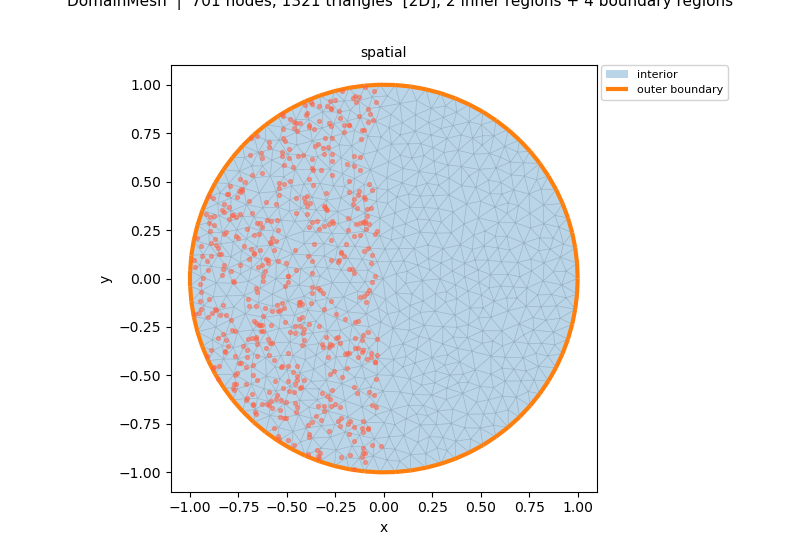

In [8]:
dv = DomainMesh((verts, faces))   # fresh stationary unit disk
dv.add_inner(lambda v: v[:, 0] < 0,                    name='left_half')
dv.add_inner([(-0.5, 0.5), (-0.5, 0.5)],               name='centre_box')
dv.add_boundary(lambda v: v[:, 0] < 0,                 name='left_arc')
dv.add_boundary(lambda v: v[:, 0] > 0,                 name='right_arc')
dv.add_boundary(lambda v: v[:, 1] > 0,                 name='top_arc')
dv.add_boundary(lambda v: v[:, 1] < 0,                 name='bottom_arc')

pts = dv.sample_interior(500, region='left_half', rng=np.random.default_rng(7))

# Filled triangles for inner regions, coloured edges for boundary regions,
# sampled collocation points overlaid
dv.plot(region='all', boundary='all', points=pts, backend='matplotlib')

---
## 6. Non-convex mesh example — U-shape

The same API works unchanged on any mesh geometry, including non-convex domains.
`pinns.meshes` ships several ready-made builders (requires **pygmsh**).

DomainMesh(2D, n_nodes=278, n_conditions=0, inner_regions=['upper_arms', 'curved_base'], boundary_regions=[])


<Axes: title={'center': 'spatial'}, xlabel='x', ylabel='y'>

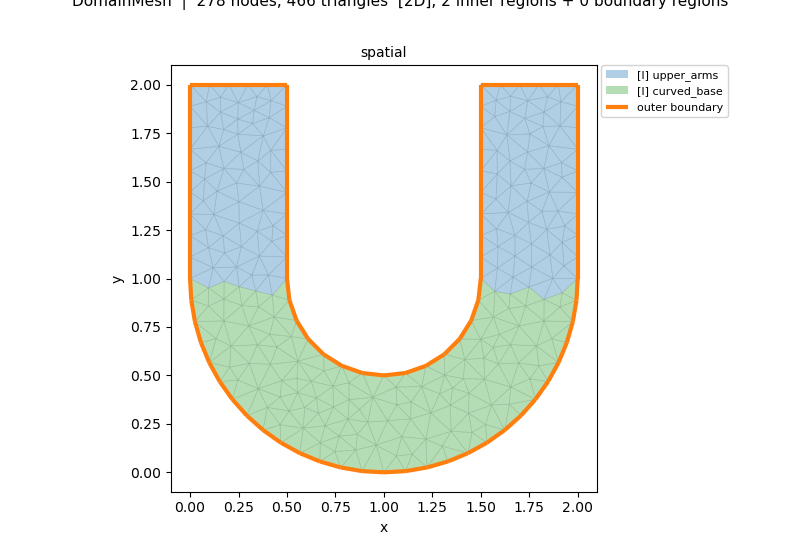

In [9]:
from pinns import meshes

# horse_shoe: two concentric semicircles + straight arms, flat open tips
# width=2.0, arm_width=0.5, arm_height=1.0  →  spans x∈[0,2], y∈[0,2]
dl = DomainMesh(meshes.horse_shoe())

# strict=False: triangles straddling the y=1.0 threshold are assigned to the
# region that claims any of their vertices, preventing gaps between regions.
dl.add_inner(lambda v: v[:, 1] > 1.0, name='upper_arms',  strict=False)  # arm section
dl.add_inner(lambda v: v[:, 1] <= 1.0, name='curved_base', strict=True)  # semicircular base

print(dl)
dl.plot(region=['upper_arms','curved_base'], boundary='all', backend='matplotlib')

DomainMesh(2D, n_nodes=278, n_conditions=0, inner_regions=['upper_arms', 'curved_base'], boundary_regions=[])


<Axes: title={'center': 'spatial'}, xlabel='x', ylabel='y'>

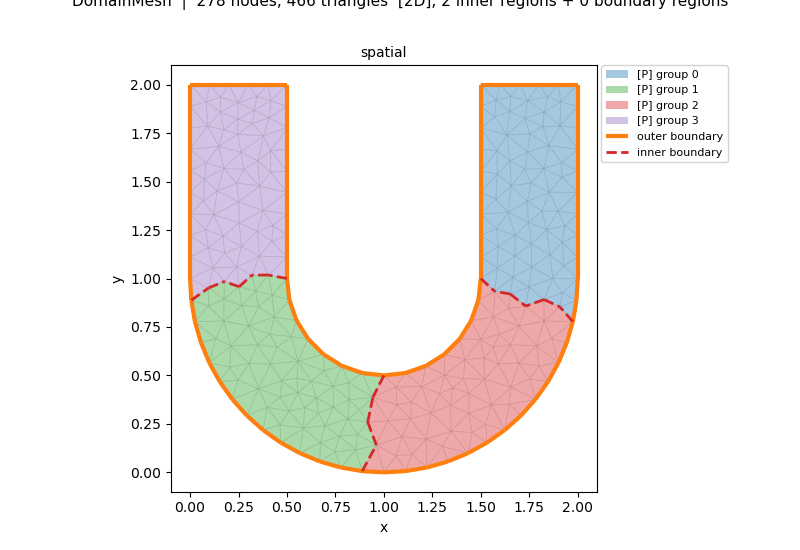

In [10]:
dl.set_partition(space=4)

print(dl)
dl.plot(region='partition', boundary='partition', backend='matplotlib')